In [22]:
%pip install --target=/storage1/fs1/jmillman/Active/DigitalTwin/python-packages tables
%pip install --target=/storage1/fs1/jmillman/Active/DigitalTwin/python-packages ipywidgets
import sys
sys.path.append('/storage1/fs1/jmillman/Active/DigitalTwin/python-packages')

  Using cached tables-3.8.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.2 kB)
  Using cached cython-3.2.4-cp38-cp38-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (7.3 kB)
  Using cached numpy-1.24.4-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
  Using cached numexpr-2.8.6-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.0 kB)
  Using cached blosc2-2.0.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached py_cpuinfo-9.0.0-py3-none-any.whl.metadata (794 bytes)
  Using cached msgpack-1.1.1-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.3 kB)
Using cached tables-3.8.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (6.5 MB)
Using cached blosc2-2.0.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.9 MB)
Using cached cython-3.2.4-cp38-cp38-many

In [23]:
import copy
import glob
import importlib
import time
import os
import shutil
import sys
from importlib import reload

import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from tqdm.notebook import tqdm

import ipywidgets

#import time

os.chdir("/storage1/fs1/jmillman/Active/DigitalTwin")


In [24]:
import celloracle as co
from celloracle.applications import Oracle_development_module
co.__version__

'0.18.0'

In [25]:
#plt.rcParams["font.family"] = "arial"
plt.rcParams["figure.figsize"] = [5,5]
%config InlineBackend.figure_format = 'retina'
plt.rcParams["savefig.dpi"] = 300

%matplotlib inline

In [26]:
#Import objects
oracle = co.load_hdf5("checkpoints/celloracle/DT_Subset_EC_Beta.celloracle.oracle")
links = co.load_hdf5("checkpoints/celloracle/DT_Subset_EC_Beta.celloracle.links")


In [27]:
#Import gradient
gradient = co.load_hdf5("checkpoints/gradient_DT_Subset_EC_Beta.celloracle.gradient")

# Please make sure that the number of cells and dimensional reduction data 
#is exact same between oracle object and gradient object
print(oracle.adata.shape, gradient.embedding.shape)

assert((oracle.adata.obsm[oracle.embedding_name] == gradient.embedding).all())

(6922, 3112) (6922, 2)


In [28]:
links.filter_links()
oracle.get_cluster_specific_TFdict_from_Links(links_object=links)
oracle.fit_GRN_for_simulation(alpha=10, use_cluster_specific_TFdict=True)

  0%|          | 0/5 [00:00<?, ?it/s]

In [29]:
# You can get the list of genes that have at least one regulatory connection in the inferred GRNs.
genes = oracle.active_regulatory_genes
len(genes)

214

In [30]:
# List of cluster name
sorted(list(oracle.adata.obs["celltype_Beta_EC_subset"].unique()))

['Beta', 'Beta-EC', 'EC', 'eEP', 'lEP']

In [31]:
# Get cell_id
clusters_end_lineage = np.where(oracle.adata.obs["celltype_Beta_EC_subset"].isin(["EC", "Beta","Beta-EC","eEP","lEP"]))[0]
clusters_beta_lineage = np.where(oracle.adata.obs["celltype_Beta_EC_subset"].isin([
                            "Beta-EC","Beta"]))[0]
clusters_ec_lineage = np.where(oracle.adata.obs["celltype_Beta_EC_subset"].isin(["EC","Beta-EC"]))[0]
clusters_onlyeBeta_lineage = np.where(oracle.adata.obs["celltype_Beta_EC_subset"].isin(['Beta']))[0]
clusters_onlyeEC_lineage = np.where(oracle.adata.obs["celltype_Beta_EC_subset"].isin(['EC']))[0]
clusters_onlyBeta_EC_lineage = np.where(oracle.adata.obs["celltype_Beta_EC_subset"].isin(['EC']))[0]

# Make a dictionary
index_dictionary = {"Endocrine": clusters_end_lineage,
                    "Beta": clusters_beta_lineage,
                    "EC": clusters_ec_lineage,
                    "onlyeBeta": clusters_onlyeBeta_lineage,
                    "onlyeEC": clusters_onlyeEC_lineage,
                    "onlyBeta-EC": clusters_onlyBeta_EC_lineage}
index_dictionary

{'Endocrine': array([   0,    1,    2, ..., 6919, 6920, 6921]),
 'Beta': array([   2,    4,    5, ..., 6855, 6861, 6876]),
 'EC': array([   0,   11,   16, ..., 6919, 6920, 6921]),
 'onlyeBeta': array([   2,    4,    5, ..., 6835, 6836, 6876]),
 'onlyeEC': array([   0,   11,   16, ..., 6919, 6920, 6921]),
 'onlyBeta-EC': array([   0,   11,   16, ..., 6919, 6920, 6921])}

In [32]:
n_propagation = 3
n_neighbors=194

file_path = "checkpoints/DT_Subset_EC_Beta.celloracle.hdf5" 
# Please use .hdf5 for extension.

In [33]:
# 0. Define parameters
def pipeline(gene_for_KO):
     
    # 1. Simulate KO
    oracle.simulate_shift(perturb_condition={gene_for_KO: 0},
                                 ignore_warning=True,
                                 n_propagation=3)
    oracle.estimate_transition_prob(n_neighbors=n_neighbors, knn_random=True, 
                                    sampled_fraction=1)
    oracle.calculate_embedding_shift(sigma_corr=0.05)

    # Do simulation for all conditions.
    for lineage_name, cell_idx in index_dictionary.items():
        
        dev = Oracle_development_module()
        # Load development flow
        dev.load_differentiation_reference_data(gradient_object=gradient)
        # Load simulation result
        dev.load_perturb_simulation_data(oracle_object=oracle, 
                                         cell_idx_use=cell_idx, 
                                         name=lineage_name)
        # Calculate inner product
        dev.calculate_inner_product()
        dev.calculate_digitized_ip(n_bins=10)
        
        # Save results in a hdf5 file.
        dev.set_hdf_path(path=file_path) 
        dev.dump_hdf5(gene=gene_for_KO, misc=lineage_name)

In [34]:
# You can get the list of genes that have at least one regulatory connection in the inferred GRNs.
genes = oracle.active_regulatory_genes #All TFs available
len(genes)

214

# Only run once

In [38]:
%%time

#Test only 1 gene
#pipeline(gene_for_KO="ARID2")

# Test pipeline with some genes
test_genes =  genes

for gene in tqdm(test_genes):
    pipeline(gene_for_KO=gene)


  0%|          | 0/214 [00:00<?, ?it/s]

CPU times: user 19h 7min 47s, sys: 27min, total: 19h 34min 48s
Wall time: 1h 35min 47s


2026-04-08 03:45:30,547 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-08 03:45:30,552 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


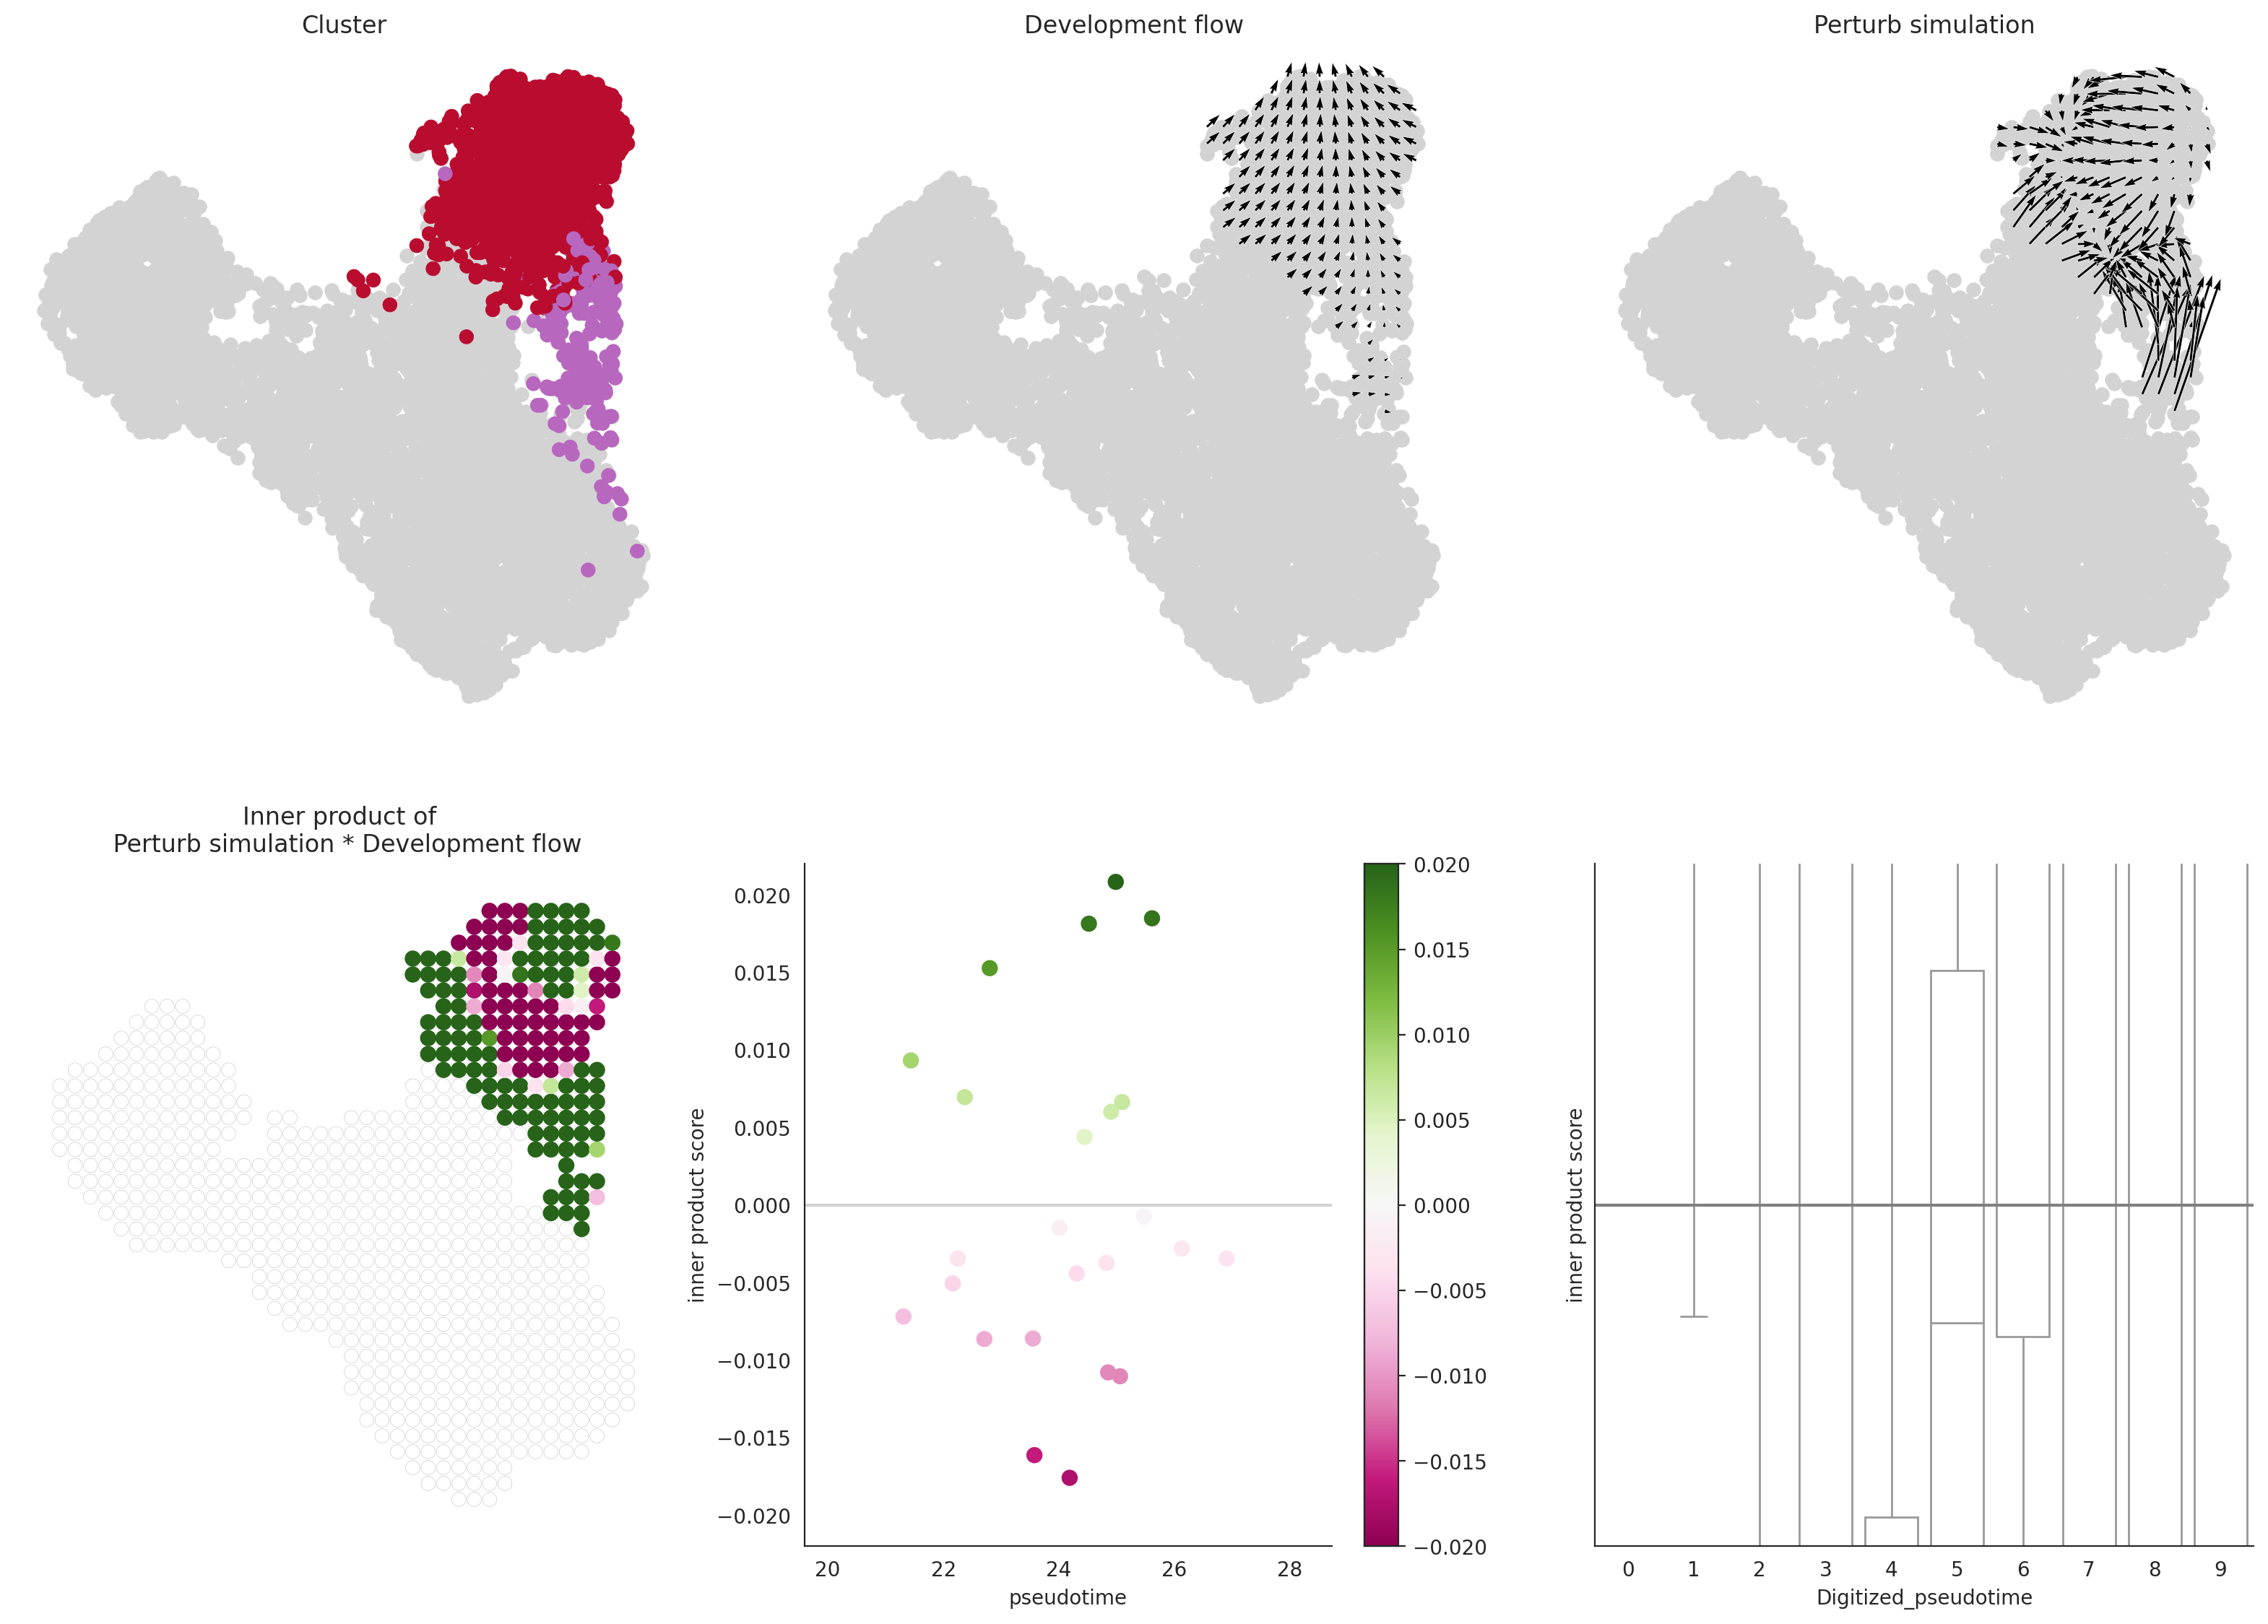

In [39]:
# Make a new Oracle_developmennt_module object to read calculation result
dev_test = Oracle_development_module()

# Read result
dev_test.set_hdf_path(path=file_path)
dev_test.load_hdf5(gene="ZEB1", misc="Beta")

# Visualize result
dev_test.visualize_development_module_layout_0(s=50, scale_for_simulation=4, s_grid=50,
                                          scale_for_pseudotime=40, vm=0.02)

In [40]:
# Make Oracle development module class to load data
file_path = "checkpoints/DT_Subset_EC_Beta.celloracle.hdf5" 
dev = Oracle_development_module()
dev.set_hdf_path(path=file_path)

In [41]:
# If we use the function below, we can see information of the saved data
info = dev.get_hdf5_info()

print("Genes\n", info["gene_list"])

print("\nSimulation conditions\n", info["misc_list"])

Genes
 ['AFP' 'AHR' 'ALX1' 'AR' 'ARHGEF12' 'ARID2' 'ARID3A' 'ARID5B' 'ARNT2'
 'ARX' 'ASCL1' 'ASCL2' 'ATF2' 'ATF6' 'BACH1' 'BACH2' 'BBX' 'BCL11A'
 'BCLAF1' 'BDP1' 'BPTF' 'CBX5' 'CCDC6' 'CDX2' 'CHD2' 'CLOCK' 'CREB1'
 'CREB3L2' 'CREB5' 'CTCF' 'CUX1' 'CUX2' 'E2F3' 'E2F7' 'EBF1' 'EBF3' 'EGR1'
 'ELF1' 'ELF2' 'ENO1' 'EPAS1' 'ESR1' 'ESR2' 'ESRRB' 'ESRRG' 'ETS1' 'ETS2'
 'ETV1' 'ETV6' 'FEV' 'FOS' 'FOXA1' 'FOXA2' 'FOXA3' 'FOXC1' 'FOXJ3' 'FOXN2'
 'FOXN3' 'FOXO1' 'FOXO3' 'FOXP1' 'FOXP2' 'GATA4' 'GLI2' 'GLI3' 'GLIS3'
 'GRHL2' 'GTF2I' 'HDAC2' 'HES1' 'HESX1' 'HIF1A' 'HIVEP1' 'HIVEP2' 'HIVEP3'
 'HLTF' 'HMGA2' 'HNF1A' 'HNF1B' 'HNF4A' 'HNF4G' 'HOXB2' 'ID1' 'ID2' 'ID3'
 'ID4' 'IKZF2' 'INSM1' 'IRX1' 'IRX2' 'ISL1' 'ISX' 'JUN' 'JUND' 'KLF12'
 'KLF5' 'KLF6' 'KLF7' 'LHX1' 'LHX4' 'LMO2' 'LMX1A' 'LMX1B' 'MAF' 'MAFB'
 'MECOM' 'MEF2A' 'MEF2C' 'MEIS1' 'MEIS2' 'MITF' 'MLXIPL' 'MXI1' 'MYCN'
 'MYEF2' 'NEUROD1' 'NEUROD4' 'NEUROG3' 'NF1' 'NFAT5' 'NFATC2' 'NFATC3'
 'NFIA' 'NFIB' 'NFKB1' 'NKX2-2' 'NKX6-1' 'NPAS3' 'NR0B1' 

# Load object with all the simulations

In [42]:
import h5py

In [43]:
# Open the HDF5 file in read-only mode
with h5py.File(file_path, 'r') as file:
    # Define the list of groups and subgroups
    groups = genes

    
    subgroups = ['onlyeBeta', 'onlyeEC', 'onlyBeta-EC']

    # Create a dictionary to store the average inner product values
    average_values = {'Group': [], 'Subgroup': [], 'Average Inner Product': []}

    # Iterate through groups and subgroups
    for group in groups:
        for subgroup in subgroups:
            # Construct the dataset path
            dataset_path = f'{group}/{subgroup}/inner_product'

            # Check if the dataset exists
            if dataset_path in file:
                # Access the inner_product dataset
                inner_product_data = file[dataset_path][()]

                # Calculate the average inner product value
                average_value = inner_product_data.mean()

                # Store the results in the dictionary
                average_values['Group'].append(group)
                average_values['Subgroup'].append(subgroup)
                average_values['Average Inner Product'].append(average_value)

# Create a DataFrame from the dictionary
df = pd.DataFrame(average_values)

# Display the DataFrame
print(df)

      Group     Subgroup  Average Inner Product
0       AFP    onlyeBeta              -0.001089
1       AFP      onlyeEC              -0.000243
2       AFP  onlyBeta-EC              -0.000243
3       AHR    onlyeBeta              -0.000377
4       AHR      onlyeEC               0.010222
..      ...          ...                    ...
637  ZNF652      onlyeEC              -0.001320
638  ZNF652  onlyBeta-EC              -0.001320
639  ZNF708    onlyeBeta               0.008333
640  ZNF708      onlyeEC              -0.005575
641  ZNF708  onlyBeta-EC              -0.005575

[642 rows x 3 columns]


In [44]:
import pandas as pd

# Make a table with one row per TF KO and one column per cell state
ps_table = df.pivot(index='Group', columns='Subgroup', values='Average Inner Product')

# Optional: sort TFs alphabetically
ps_table = ps_table.sort_index()

# Optional: remove the column/index names for cleaner export
ps_table.index.name = 'TF_KO'
ps_table.columns.name = None

# Preview
print(ps_table)

# Save as CSV
ps_table.to_csv("outputs/celloracle_tables/DT_Subset_Beta_EC/PS_scores_per_TFKO_per_cellstate.csv")
#Table S23

          onlyBeta-EC  onlyeBeta   onlyeEC
TF_KO                                     
AFP         -0.000243  -0.001089 -0.000243
AHR          0.010222  -0.000377  0.010222
ALX1        -0.001642  -0.002670 -0.001642
AR          -0.000072  -0.000265 -0.000072
ARHGEF12     0.000565  -0.006946  0.000565
...               ...        ...       ...
ZNF148       0.002294   0.001640  0.002294
ZNF423      -0.001139   0.015190 -0.001139
ZNF431      -0.000816   0.002203 -0.000816
ZNF652      -0.001320  -0.003846 -0.001320
ZNF708      -0.005575   0.008333 -0.005575

[214 rows x 3 columns]


# Quadrant plots

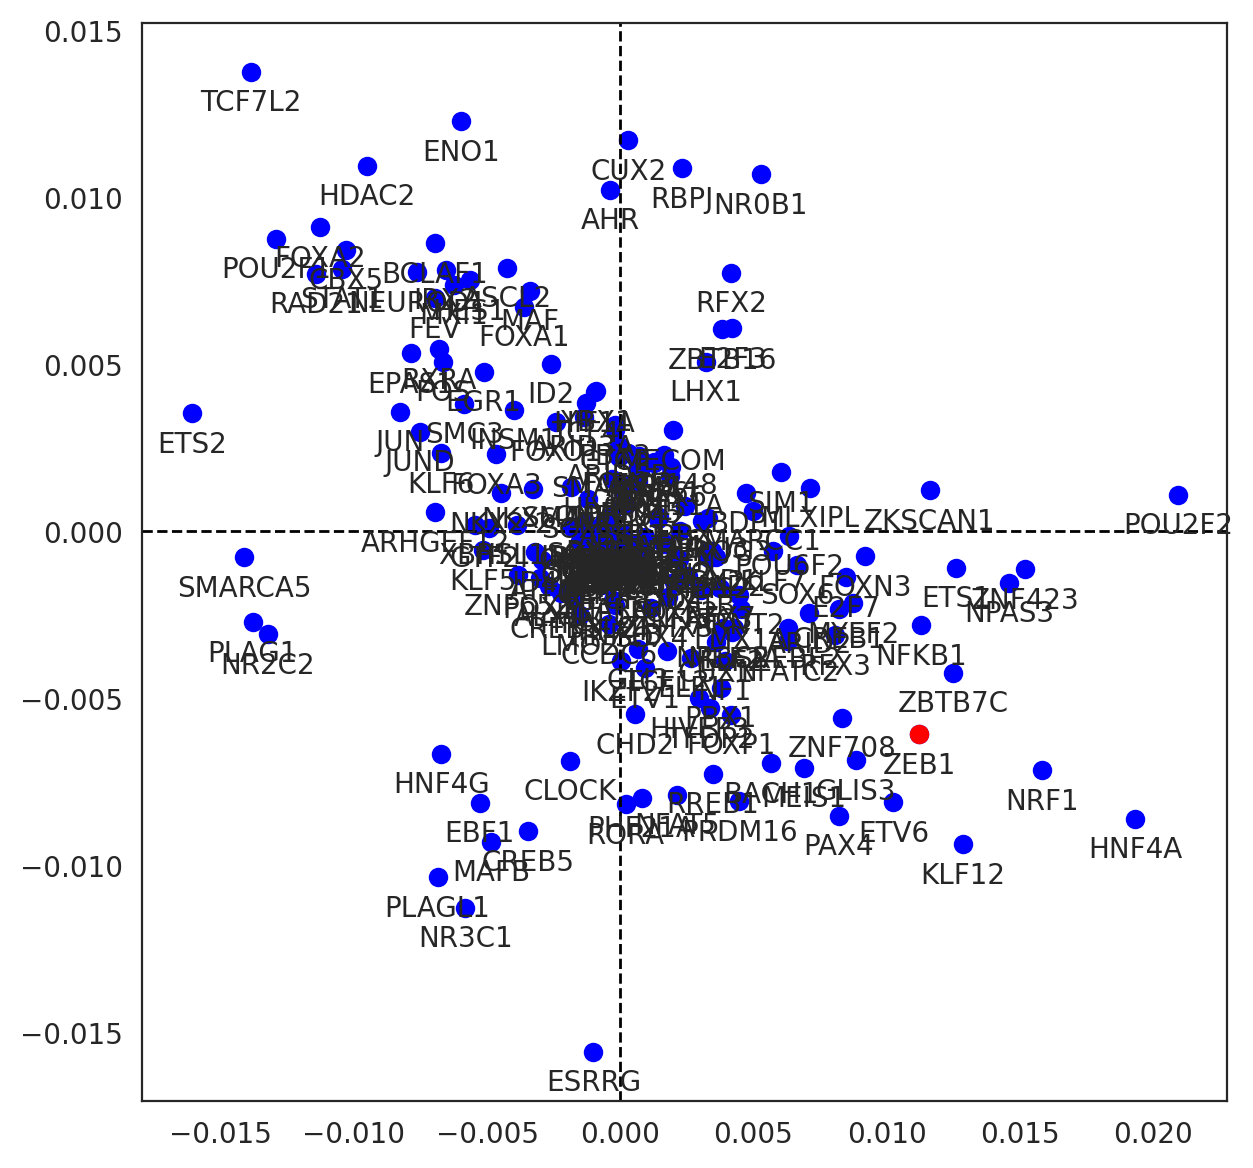

In [16]:
#Full cuadrants
import pandas as pd
import matplotlib.pyplot as plt

# Create the figure with desired size
plt.figure(figsize=(7, 7))

# Assuming df is your existing DataFrame
# df = pd.read_csv('your_dataframe.csv')

# Create a pivot table
pivot_table = df.pivot(index='Group', columns='Subgroup', values='Average Inner Product')

# Filter
filtered_data = pivot_table

# Plot blue points
plt.scatter(filtered_data['onlyeBeta'], filtered_data['onlyeEC'], color='blue')

# Highlight ZEB1 in red
for gene in ['ZEB1']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['onlyeBeta'][gene],
                    pivot_table['onlyeEC'][gene],
                    color='red')

        
# Label all genes in filtered_data
for gene in filtered_data.index:
    plt.annotate(
        gene,
        (filtered_data.loc[gene, 'onlyeBeta'], filtered_data.loc[gene, 'onlyeEC']),
        xytext=(0, -6),
        textcoords='offset points',
        ha='center',
        va='top',
        fontsize=10  # reduce if too crowded
    )

# Axes and lines
#plt.xlabel('Beta')
#plt.ylabel('EC')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

# Save at 600 dpi
plt.savefig(
    "outputs/celloracle_figures/DT_Subset_EC_Beta/PS_scatter_Beta_vs_EC_all_quadrants.png",
    dpi=600,
    bbox_inches="tight"  # trims extra whitespace
)

plt.show()

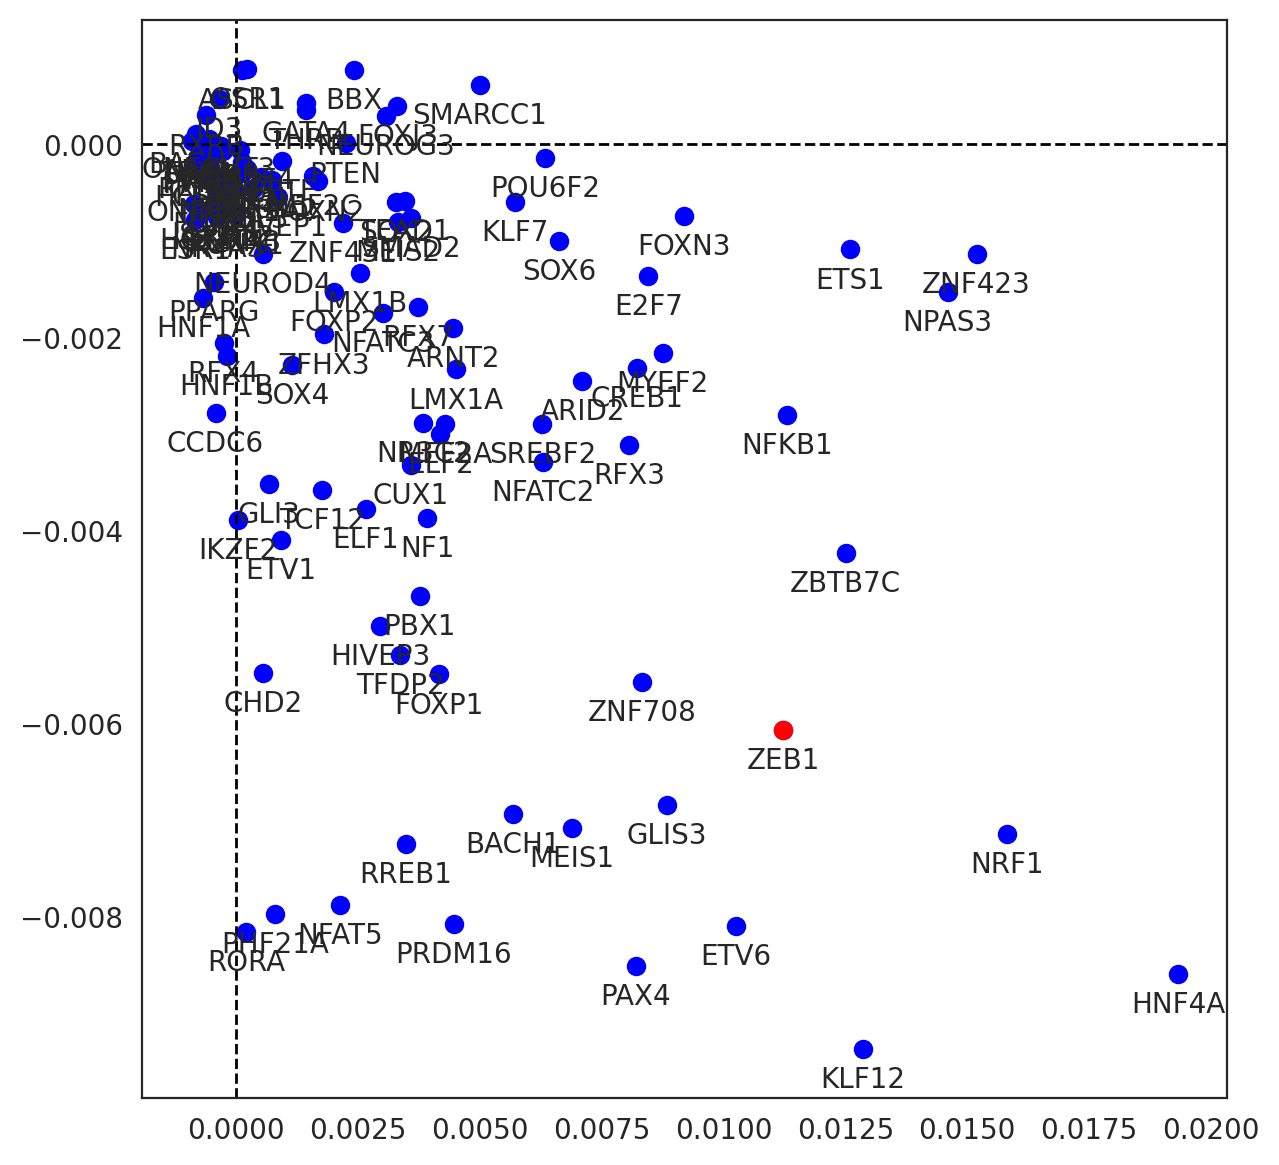

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Create the figure with desired size
plt.figure(figsize=(7, 7))

# Assuming df is your existing DataFrame
# df = pd.read_csv('your_dataframe.csv')

# Create a pivot table
pivot_table = df.pivot(index='Group', columns='Subgroup', values='Average Inner Product')

# Filter
filtered_data = pivot_table[(pivot_table['onlyeBeta'] > -0.001) &
                            (pivot_table['onlyeEC'] < 0.001)]

# Plot blue points
plt.scatter(filtered_data['onlyeBeta'], filtered_data['onlyeEC'], color='blue')

# Highlight ZEB1 in red
for gene in ['ZEB1']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['onlyeBeta'][gene],
                    pivot_table['onlyeEC'][gene],
                    color='red')

        
# Label all genes in filtered_data
for gene in filtered_data.index:
    plt.annotate(
        gene,
        (filtered_data.loc[gene, 'onlyeBeta'], filtered_data.loc[gene, 'onlyeEC']),
        xytext=(0, -6),
        textcoords='offset points',
        ha='center',
        va='top',
        fontsize=10  # reduce if too crowded
    )

# Axes and lines
#plt.xlabel('Beta')
#plt.ylabel('EC')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

# Save at 600 dpi
plt.savefig(
    "outputs/celloracle_figures/DT_Subset_EC_Beta/PS_scatter_Beta_vs_EC_all_gene_names.png",
    dpi=600,
    bbox_inches="tight"  # trims extra whitespace
)

plt.show()

In [39]:
# Save as CSV
pivot_table.to_csv('outputs/celloracle_tables/DT_Beta_EC_Simulation_PS.csv', index=True)

In [40]:
pivot_table

Subgroup,onlyBeta-EC,onlyeBeta,onlyeEC
Group,,,
AFP,-0.000243,-0.001089,-0.000243
AHR,0.010222,-0.000377,0.010222
ALX1,-0.001642,-0.002670,-0.001642
AR,-0.000072,-0.000265,-0.000072
ARHGEF12,0.000565,-0.006946,0.000565
...,...,...,...
ZNF148,0.002294,0.001640,0.002294
ZNF423,-0.001139,0.015190,-0.001139
ZNF431,-0.000816,0.002203,-0.000816


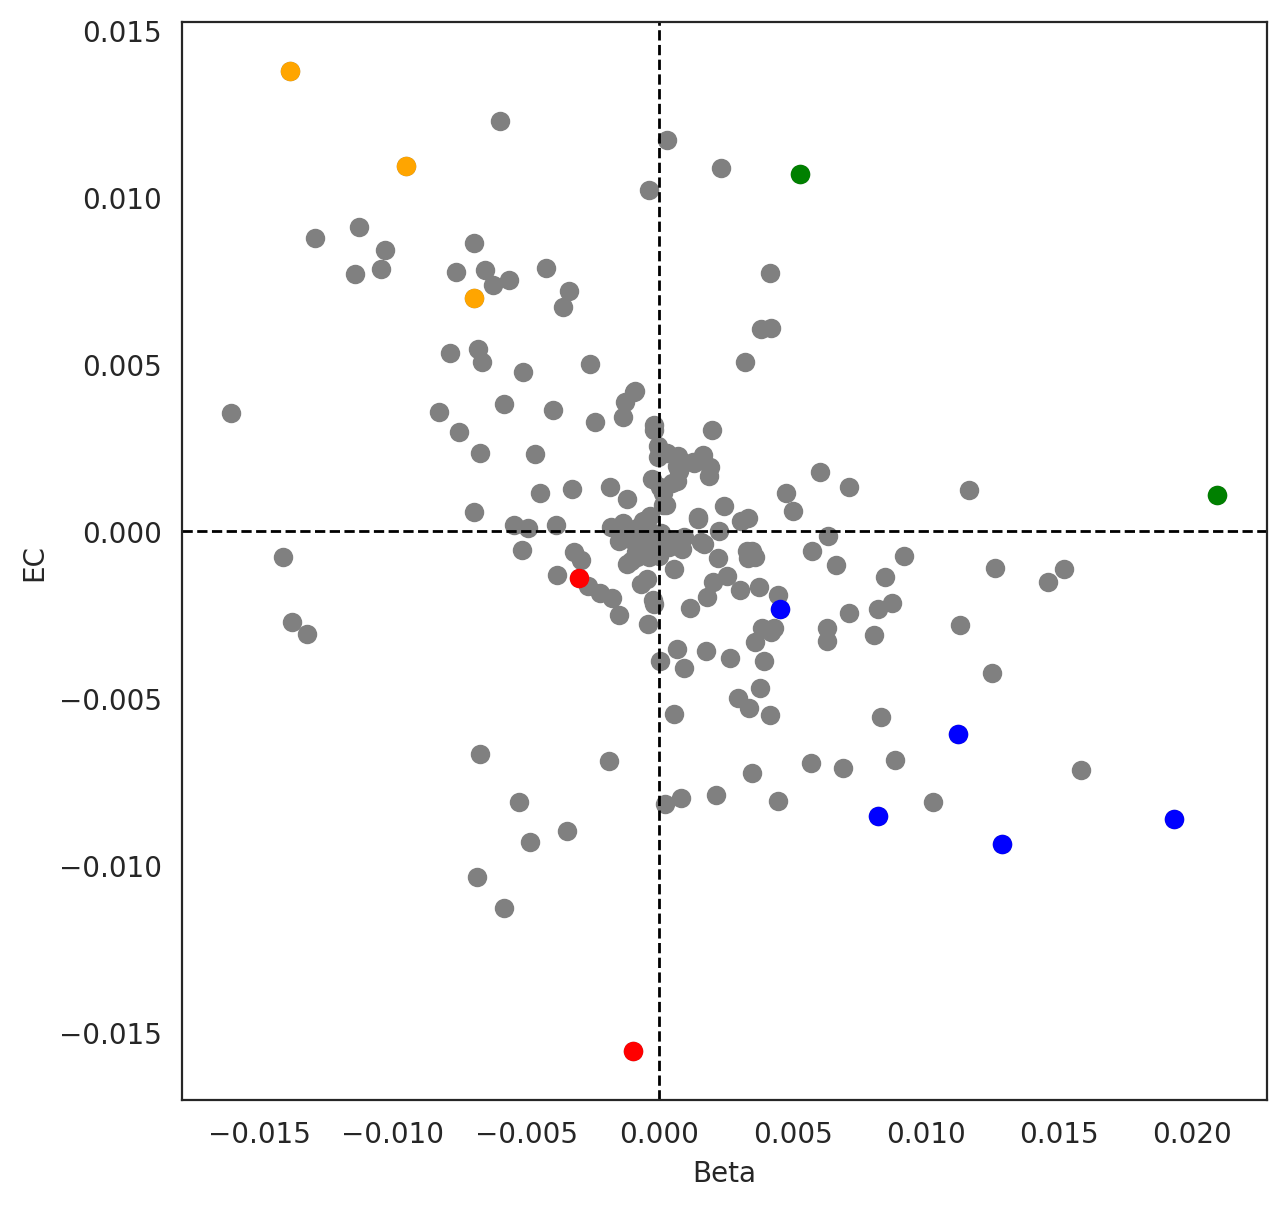

In [18]:
# Create the figure with desired size
plt.figure(figsize=(7, 7))

# Assuming df is your existing DataFrame
# df = pd.read_csv('your_dataframe.csv')

# Create a pivot table
pivot_table = df.pivot(index='Group', columns='Subgroup', values='Average Inner Product')

# Filter
filtered_data = pivot_table

# Plot blue points
plt.scatter(filtered_data['onlyeBeta'], filtered_data['onlyeEC'], color='gray')

# Highlight in blue
for gene in ['ZEB1','HNF4A','KLF12','PAX4', 'LMX1A']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['onlyeBeta'][gene],
                    pivot_table['onlyeEC'][gene],
                    color='blue')

# Highlight in red
for gene in ['PDX1','ESRRG']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['onlyeBeta'][gene],
                    pivot_table['onlyeEC'][gene],
                    color='red')

# Highlight in green
for gene in ['NR0B1','POU2F2']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['onlyeBeta'][gene],
                    pivot_table['onlyeEC'][gene],
                    color='green')

# Highlight in orange
for gene in ['TCF7L2','FEV','HDAC2']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['onlyeBeta'][gene],
                    pivot_table['onlyeEC'][gene],
                    color='orange')


        
# Axes and lines
plt.xlabel('Beta')
plt.ylabel('EC')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

# Save at 600 dpi
plt.savefig(
    "outputs/celloracle_figures/DT_Subset_EC_Beta/PS_scatter_Beta_vs_EC_all_quadrants_no_nametags.png",
    dpi=600,
    bbox_inches="tight"  # trims extra whitespace
)

plt.show()

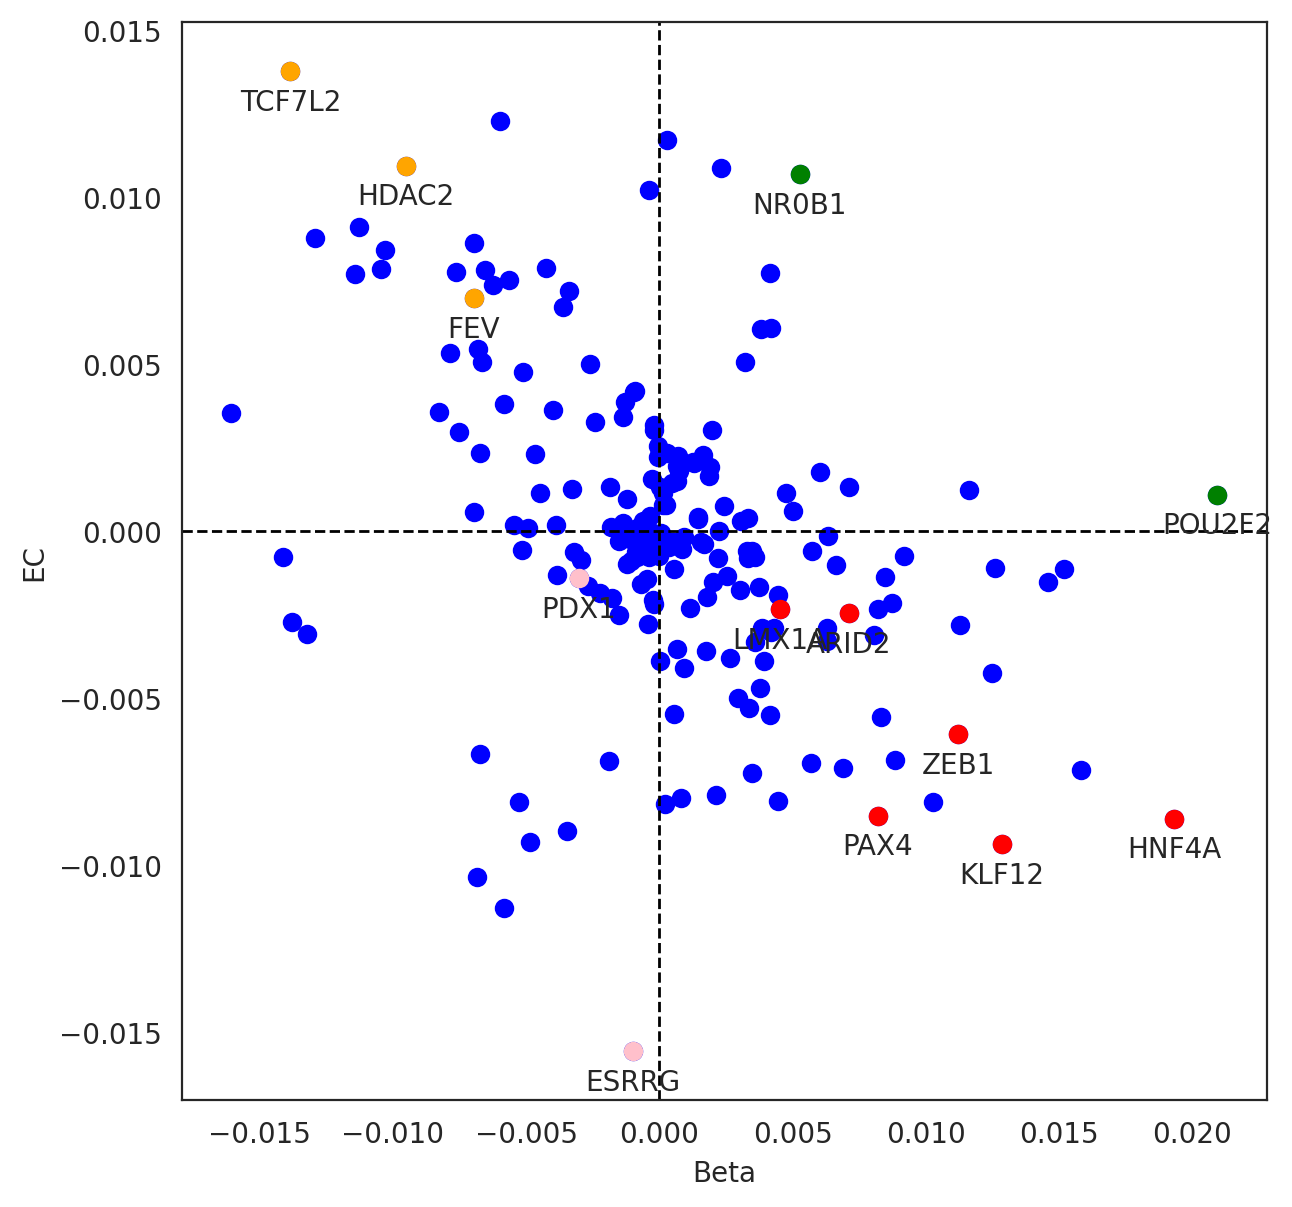

In [32]:
# Create the figure with desired size
plt.figure(figsize=(7, 7))

# Assuming df is your existing DataFrame
# df = pd.read_csv('your_dataframe.csv')

# Create a pivot table
pivot_table = df.pivot(index='Group', columns='Subgroup', values='Average Inner Product')

# Filter
filtered_data = pivot_table

# Plot blue points
plt.scatter(filtered_data['onlyeBeta'], filtered_data['onlyeEC'], color='blue')

# Highlight in red
for gene in ['ZEB1','HNF4A','KLF12','PAX4', 'LMX1A']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['onlyeBeta'][gene],
                    pivot_table['onlyeEC'][gene],
                    color='red')

# Highlight in pink
for gene in ['PDX1','ESRRG']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['onlyeBeta'][gene],
                    pivot_table['onlyeEC'][gene],
                    color='pink')

# Highlight in green
for gene in ['NR0B1','POU2F2']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['onlyeBeta'][gene],
                    pivot_table['onlyeEC'][gene],
                    color='green')

# Highlight in orange
for gene in ['TCF7L2','FEV','HDAC2']:
    if gene in pivot_table.index:
        plt.scatter(pivot_table['onlyeBeta'][gene],
                    pivot_table['onlyeEC'][gene],
                    color='orange')
        
# Label only ZEB1 below the dots
for gene in filtered_data.index:
    if gene in ['ZEB1','PDX1','HNF4A','KLF12','PAX4', 'LMX1A',
               'TCF7L2','FEV','HDAC2',
                'NR0B1','POU2F2','PDX1','ESRRG'           ]:
        plt.annotate(
            gene,
            (filtered_data.loc[gene, 'onlyeBeta'], filtered_data.loc[gene, 'onlyeEC']),
            xytext=(0, -6),
            textcoords='offset points',
            ha='center',
            va='top'
        )
        
# Axes and lines
plt.xlabel('Beta')
plt.ylabel('EC')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

# Save at 600 dpi
plt.savefig(
    "outputs/celloracle_figures/DT_Subset_EC_Beta/PS_scatter_Beta_vs_EC_all_quadrants_only_GOI_name.png",
    dpi=600,
    bbox_inches="tight"  # trims extra whitespace
)

plt.show()

In [96]:
#  - Karma para el Alma by Tren a Marte